# 20 — Dictionary and noise sweep

Сравнение качества идентификации и робастности при разных словарях и уровнях шума.

In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.basis import get_basis
from src.control import candidate_gains, closed_loop_jacobian
from src.experiments import compute_tail_metrics, summarize_tail_metrics, is_hurwitz, residual_statistics, add_gaussian_noise
from src.identification import fit_identified_model, predict_vector_field, rmse
from src.lyapunov import numerical_jacobian, solve_lyapunov, lyapunov_value, evaluate_lyapunov_grid
from src.simulation import simulate_batch, uncertain_dynamics
from src.systems import cross_coupled_uncontrolled
from src.uncertainty import compute_residuals, estimate_epsilon, bounded_disturbance, compute_bounding_box
from src.utils import ensure_dir, save_dataframe, save_json, get_project_root, set_seed

ROOT = get_project_root()

In [5]:
set_seed(42)
rng = np.random.default_rng(42)
EXP_RESULTS = ROOT / 'results' / 'archive' / 'experiments_v2'
EXP_DATA = ROOT / 'data' / 'processed' / 'experiments_v2'
for p in [EXP_RESULTS / 'figures', EXP_RESULTS / 'tables', EXP_RESULTS / 'metrics', EXP_DATA]:
    ensure_dir(p)

# reference clean dataset
initials = np.array([[-1.2,-0.8],[-1.0,0.7],[-0.6,1.1],[0.5,-1.0],[1.0,0.9],[1.3,-0.4]], dtype=float)
t_eval = np.linspace(0, 10, 250)
traj_true = simulate_batch(cross_coupled_uncontrolled, initials, (0,10), t_eval)
X = np.vstack([st for _, st in traj_true])
Xdot = np.vstack([np.array([cross_coupled_uncontrolled(float(t), s) for t, s in zip(ts, st)]) for ts, st in traj_true])
save_dataframe(pd.DataFrame(np.hstack([X, Xdot]), columns=['x1','x2','xdot1','xdot2']), EXP_DATA / 'reference_dataset.csv')


In [6]:
dictionaries = ['linear', 'linear_with_constant', 'quadratic_full', 'reduced_quadratic_no_cross', 'reduced_cross_only']
noise_levels = [0.0, 0.01, 0.03, 0.05]
B = np.array([[0.0], [1.0]])
initials_unc = np.array([[-1.0,-0.8],[-0.8,1.0],[0.8,-1.0],[1.1,0.9]], dtype=float)
t_unc = np.linspace(0, 10, 280)

rows = []
closed_rows = []
ultimate_radius_json = {}

for dictionary_name in dictionaries:
    basis_fn = get_basis(dictionary_name)
    for sigma in noise_levels:
        X_noisy = add_gaussian_noise(X, sigma, rng)
        Xdot_noisy = add_gaussian_noise(Xdot, sigma, rng)

        fit = fit_identified_model(X_noisy, Xdot_noisy, basis_fn, basis_name=dictionary_name)
        Xdot_hat = predict_vector_field(X, basis_fn, fit.coefficients)
        residuals = compute_residuals(Xdot, Xdot_hat)
        epsilon = estimate_epsilon(np.linalg.norm(residuals, axis=1), q=0.95)

        A = numerical_jacobian(lambda x: predict_vector_field(x[None, :], basis_fn, fit.coefficients)[0], np.zeros(2))
        eig_A = np.linalg.eigvals(A)
        open_loop_stable = is_hurwitz(A)

        try:
            P = solve_lyapunov(A, np.eye(2))
            p_pos_def = bool(np.all(np.linalg.eigvalsh(P) > 0))
        except Exception:
            P = np.full((2, 2), np.nan)
            p_pos_def = False

        fhat = lambda t, x, basis_fn=basis_fn, c=fit.coefficients: predict_vector_field(x[None, :], basis_fn, c)[0]
        unc_dyn = uncertain_dynamics(fhat, lambda t, eps=epsilon: bounded_disturbance(t, eps))
        unc_traj = simulate_batch(unc_dyn, initials_unc, (0,10), t_unc)
        unc_tail_summary = summarize_tail_metrics([compute_tail_metrics(st) for _, st in unc_traj])

        row = {
            'dictionary_name': dictionary_name,
            'noise_sigma': sigma,
            'rmse': rmse(Xdot, Xdot_hat),
            'mae': float(np.mean(np.abs(Xdot - Xdot_hat))),
            'epsilon_q95': float(epsilon),
            'open_loop_stable': open_loop_stable,
            'open_loop_ultimate_radius': unc_tail_summary['ultimate_radius_estimate'],
            'notes': '' if open_loop_stable else 'open-loop unstable linearization',
            **residual_statistics(residuals),
        }

        closed_loop_json = {}
        best_radius = np.inf
        for gain_name, K in candidate_gains().items():
            A_cl = closed_loop_jacobian(A, B, K)
            eig_A_cl = np.linalg.eigvals(A_cl)
            stable_cl = is_hurwitz(A_cl)
            cl_dyn = uncertain_dynamics(lambda t, x, K=K: fhat(t, x) + (B @ (K @ x)).reshape(-1), lambda t, eps=epsilon: bounded_disturbance(t, eps))
            cl_traj = simulate_batch(cl_dyn, initials_unc, (0,10), t_unc)
            cl_tail_summary = summarize_tail_metrics([compute_tail_metrics(st) for _, st in cl_traj])
            radius = cl_tail_summary['ultimate_radius_estimate']
            best_radius = min(best_radius, radius)

            row[f'{gain_name}_ultimate_radius'] = radius
            closed_rows.append({
                'dictionary_name': dictionary_name,
                'noise_sigma': sigma,
                'gain_name': gain_name,
                'stable_closed_loop': stable_cl,
                'ultimate_radius_estimate': radius,
                'mean_tail_radius': cl_tail_summary['mean_tail_radius'],
                'max_tail_radius': cl_tail_summary['max_tail_radius'],
            })
            closed_loop_json[gain_name] = {
                'A_cl': A_cl.tolist(),
                'eig_A_cl_real_parts': np.real(eig_A_cl).tolist(),
                'stable_closed_loop': stable_cl,
                **cl_tail_summary,
            }

        row['best_closed_loop_radius'] = best_radius
        rows.append(row)
        ultimate_radius_json[f'{dictionary_name}|sigma={sigma:.2f}'] = {
            'A': A.tolist(),
            'eig_A_real_parts': np.real(eig_A).tolist(),
            'P_positive_definite': p_pos_def,
            'open_loop': unc_tail_summary,
            'closed_loop': closed_loop_json,
        }

summary_df = pd.DataFrame(rows)
closed_df = pd.DataFrame(closed_rows)

summary_df.to_csv(EXP_RESULTS / 'tables' / 'dictionary_noise_summary.csv', index=False)
closed_df.to_csv(EXP_RESULTS / 'tables' / 'closed_loop_summary.csv', index=False)
save_json(json.loads(summary_df.to_json(orient='records')), EXP_RESULTS / 'metrics' / 'dictionary_noise_summary.json')
save_json(ultimate_radius_json, EXP_RESULTS / 'metrics' / 'ultimate_radius_comparison.json')

summary_df.head()


,dictionary_name,noise_sigma,rmse,mae,epsilon_q95,open_loop_stable,open_loop_ultimate_radius,notes,max_residual_norm,mean_residual_norm,median_residual_norm,q90_residual_norm,q95_residual_norm,q99_residual_norm,mild_ultimate_radius,medium_ultimate_radius,aggressive_ultimate_radius,best_closed_loop_radius
0,linear,0.00,0.104888,0.030747,0.300910,True,0.154259,,1.666296,0.046057,0.001806,0.095876,0.300910,0.671590,0.138069,0.125019,0.113069,0.113069
1,linear,0.01,0.104895,0.030736,0.300341,True,0.154034,,1.667986,0.046027,0.001802,0.095173,0.300341,0.662684,0.137856,0.124788,0.112803,0.112803
2,linear,0.03,0.105334,0.030927,0.293408,True,0.152217,,1.698762,0.046272,0.001868,0.099503,0.293408,0.658240,0.135455,0.122521,0.110509,0.110509
3,linear,0.05,0.107875,0.031635,0.290236,True,0.152157,,1.727435,0.047601,0.001902,0.109349,0.290236,0.701265,0.135208,0.122049,0.109518,0.109518
4,linear_with_constant,0.00,0.102675,0.041233,0.281116,True,0.129197,,1.610916,0.065637,0.030906,0.083306,0.281116,0.648785,0.108907,0.102796,0.095884,0.095884


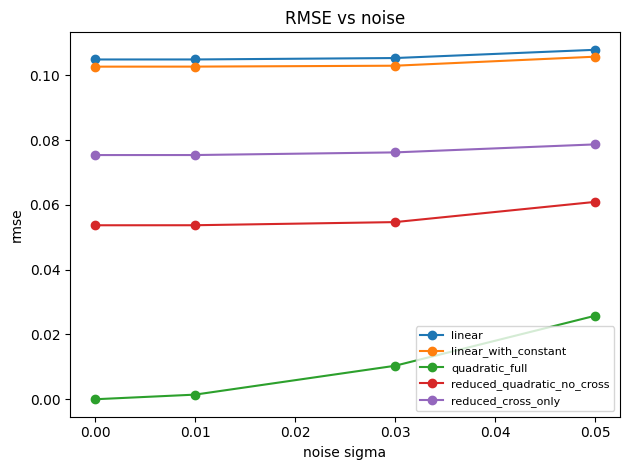

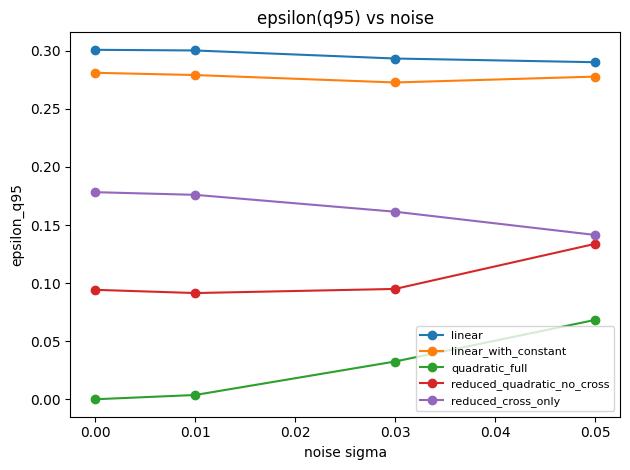

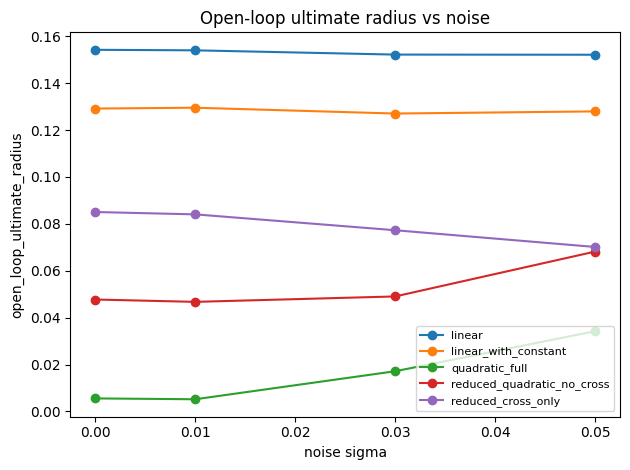

In [7]:
# Overview plots
for metric, title, fname in [
    ('rmse', 'RMSE vs noise', 'rmse_vs_noise.png'),
    ('epsilon_q95', 'epsilon(q95) vs noise', 'epsilon_vs_noise.png'),
    ('open_loop_ultimate_radius', 'Open-loop ultimate radius vs noise', 'open_loop_ultimate_radius_vs_noise.png'),
]:
    plt.figure()
    for dictionary_name in dictionaries:
        sub = summary_df[summary_df['dictionary_name'] == dictionary_name].sort_values('noise_sigma')
        plt.plot(sub['noise_sigma'], sub[metric], marker='o', label=dictionary_name)
    plt.xlabel('noise sigma')
    plt.ylabel(metric)
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(EXP_RESULTS / 'figures' / fname, dpi=220)
    plt.show()


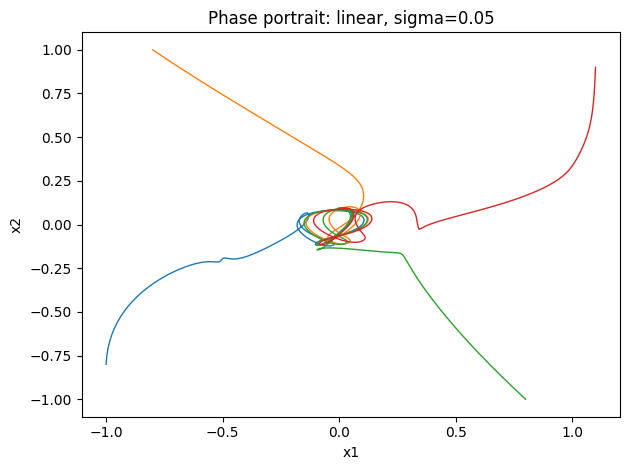

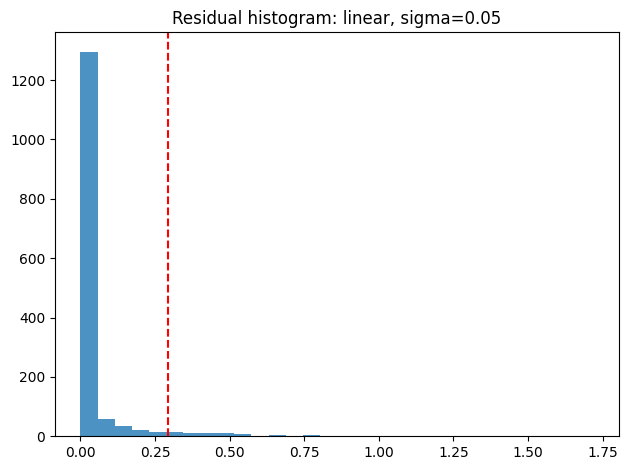

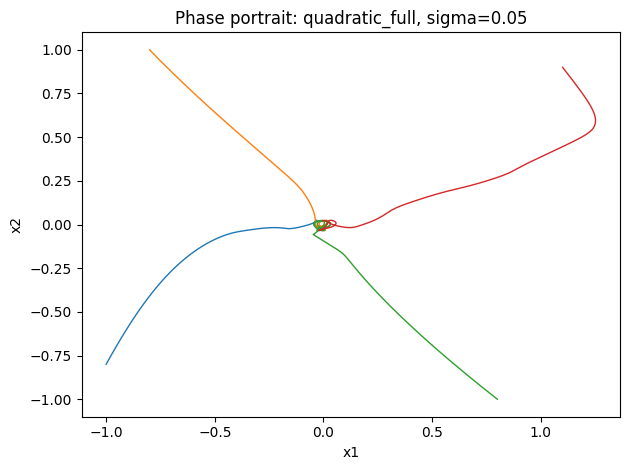

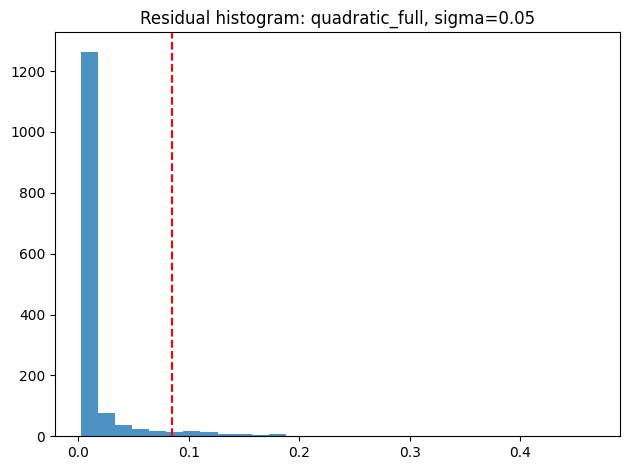

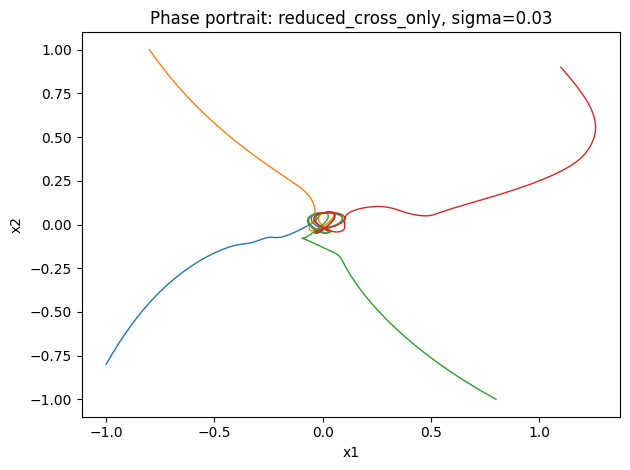

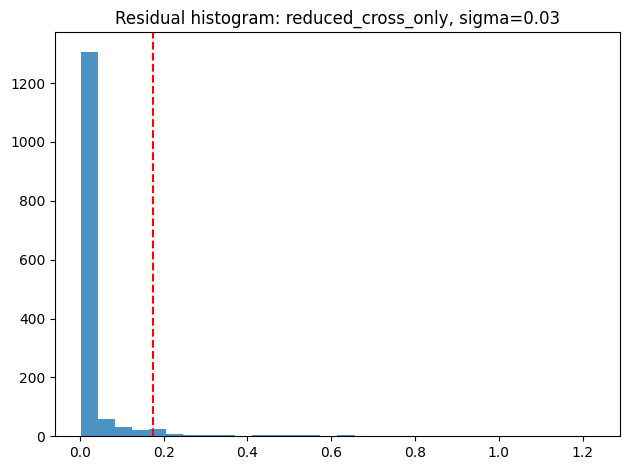

In [8]:
# Detailed selected cases
selected_cases = [('linear', 0.05), ('quadratic_full', 0.05), ('reduced_cross_only', 0.03)]
initials_unc = np.array([[-1.0,-0.8],[-0.8,1.0],[0.8,-1.0],[1.1,0.9]], dtype=float)
t_unc = np.linspace(0, 10, 280)

for dictionary_name, sigma in selected_cases:
    basis_fn = get_basis(dictionary_name)
    fit = fit_identified_model(add_gaussian_noise(X, sigma, rng), add_gaussian_noise(Xdot, sigma, rng), basis_fn, basis_name=dictionary_name)
    Xdot_hat = predict_vector_field(X, basis_fn, fit.coefficients)
    residuals = compute_residuals(Xdot, Xdot_hat)
    epsilon = estimate_epsilon(np.linalg.norm(residuals, axis=1), q=0.95)

    fhat = lambda t, x, basis_fn=basis_fn, c=fit.coefficients: predict_vector_field(x[None, :], basis_fn, c)[0]
    unc_traj = simulate_batch(uncertain_dynamics(fhat, lambda t, eps=epsilon: bounded_disturbance(t, eps)), initials_unc, (0,10), t_unc)

    plt.figure()
    for _, st in unc_traj:
        plt.plot(st[:,0], st[:,1], lw=1.0)
    plt.xlabel('x1'); plt.ylabel('x2')
    plt.title(f'Phase portrait: {dictionary_name}, sigma={sigma}')
    plt.tight_layout()
    plt.savefig(EXP_RESULTS / 'figures' / f'phase_{dictionary_name}_sigma_{sigma:.2f}.png', dpi=220)
    plt.show()

    plt.figure()
    plt.hist(np.linalg.norm(residuals, axis=1), bins=30, alpha=0.8)
    plt.axvline(epsilon, color='r', ls='--')
    plt.title(f'Residual histogram: {dictionary_name}, sigma={sigma}')
    plt.tight_layout()
    plt.savefig(EXP_RESULTS / 'figures' / f'residual_hist_{dictionary_name}_sigma_{sigma:.2f}.png', dpi=220)
    plt.show()


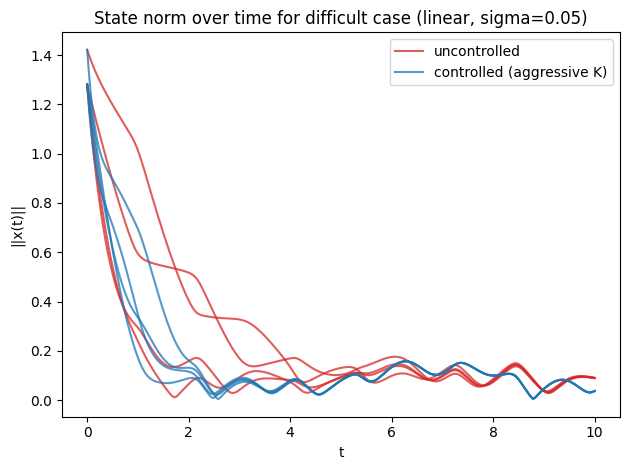

In [9]:
# Controlled vs uncontrolled for difficult case
case_dict, case_sigma = 'linear', 0.05
basis_fn = get_basis(case_dict)
fit = fit_identified_model(add_gaussian_noise(X, case_sigma, rng), add_gaussian_noise(Xdot, case_sigma, rng), basis_fn, basis_name=case_dict)
fhat = lambda t, x: predict_vector_field(x[None, :], basis_fn, fit.coefficients)[0]
residuals = compute_residuals(Xdot, predict_vector_field(X, basis_fn, fit.coefficients))
epsilon = estimate_epsilon(np.linalg.norm(residuals, axis=1), q=0.95)

B = np.array([[0.0], [1.0]])
K = candidate_gains()['aggressive']
traj_u = simulate_batch(uncertain_dynamics(fhat, lambda t: bounded_disturbance(t, epsilon)), np.array([[-1.0,-0.8],[-0.8,1.0],[0.8,-1.0],[1.1,0.9]], dtype=float), (0,10), np.linspace(0,10,280))
traj_c = simulate_batch(uncertain_dynamics(lambda t, x: fhat(t, x) + (B @ (K @ x)).reshape(-1), lambda t: bounded_disturbance(t, epsilon)), np.array([[-1.0,-0.8],[-0.8,1.0],[0.8,-1.0],[1.1,0.9]], dtype=float), (0,10), np.linspace(0,10,280))

plt.figure()
for i, (tt, st) in enumerate(traj_u):
    plt.plot(tt, np.linalg.norm(st, axis=1), color='tab:red', alpha=0.75, label='uncontrolled' if i == 0 else None)
for i, (tt, st) in enumerate(traj_c):
    plt.plot(tt, np.linalg.norm(st, axis=1), color='tab:blue', alpha=0.75, label='controlled (aggressive K)' if i == 0 else None)
plt.xlabel('t'); plt.ylabel('||x(t)||')
plt.title('State norm over time for difficult case (linear, sigma=0.05)')
plt.legend()
plt.tight_layout()
plt.savefig(EXP_RESULTS / 'figures' / 'state_norm_controlled_vs_uncontrolled_linear_sigma_0.05.png', dpi=220)
plt.show()


In [13]:
# Human-readable summary
best_noiseless = summary_df[summary_df['noise_sigma'] == 0.0].sort_values('rmse').iloc[0]
robust_noise = summary_df[summary_df['noise_sigma'] == 0.05].sort_values('rmse').iloc[0]
print('Best dictionary at sigma=0.0 by RMSE:', best_noiseless['dictionary_name'])
print('Best dictionary at sigma=0.05 by RMSE:', robust_noise['dictionary_name'])
print('\nAverage epsilon increase from sigma=0.0 to sigma=0.05:')
for d in dictionaries:
    sub = summary_df[summary_df['dictionary_name'] == d].sort_values('noise_sigma')
    delta = float(sub[sub['noise_sigma'] == 0.05]['epsilon_q95'].iloc[0] - sub[sub['noise_sigma'] == 0.0]['epsilon_q95'].iloc[0])
    print(f'  {d}: +{delta:.4f}')

summary_df.sort_values(['noise_sigma', 'rmse']).head(10)

Best dictionary at sigma=0.0 by RMSE: quadratic_full
Best dictionary at sigma=0.05 by RMSE: quadratic_full

Average epsilon increase from sigma=0.0 to sigma=0.05:
  linear: +-0.0107
  linear_with_constant: +-0.0033
  quadratic_full: +0.0683
  reduced_quadratic_no_cross: +0.0396
  reduced_cross_only: +-0.0368


,dictionary_name,noise_sigma,rmse,mae,epsilon_q95,open_loop_stable,open_loop_ultimate_radius,notes,max_residual_norm,mean_residual_norm,median_residual_norm,q90_residual_norm,q95_residual_norm,q99_residual_norm,mild_ultimate_radius,medium_ultimate_radius,aggressive_ultimate_radius,best_closed_loop_radius
8,quadratic_full,0.00,1.494125e-16,6.207713e-17,4.965068e-16,True,0.005533,,1.790181e-15,9.835010e-17,3.203637e-17,2.329221e-16,4.965068e-16,9.930137e-16,0.000015,0.000002,1.813760e-07,1.813760e-07
12,reduced_quadratic_no_cross,0.00,5.370791e-02,1.148309e-02,9.423878e-02,True,0.047728,,8.811384e-01,2.296618e-02,6.054647e-03,2.736105e-02,9.423878e-02,4.317610e-01,0.042545,0.038563,3.555350e-02,3.555350e-02
16,reduced_cross_only,0.00,7.538399e-02,2.551339e-02,1.783128e-01,True,0.085055,,1.191020e+00,5.102679e-02,2.930876e-02,6.433737e-02,1.783128e-01,5.487538e-01,0.069685,0.062453,5.766806e-02,5.766806e-02
4,linear_with_constant,0.00,1.026745e-01,4.123342e-02,2.811159e-01,True,0.129197,,1.610916e+00,6.563696e-02,3.090573e-02,8.330583e-02,2.811159e-01,6.487852e-01,0.108907,0.102796,9.588368e-02,9.588368e-02
0,linear,0.00,1.048877e-01,3.074729e-02,3.009098e-01,True,0.154259,,1.666296e+00,4.605737e-02,1.806138e-03,9.587600e-02,3.009098e-01,6.715896e-01,0.138069,0.125019,1.130686e-01,1.130686e-01
9,quadratic_full,0.01,1.426159e-03,7.096963e-04,3.656189e-03,True,0.005177,,1.778220e-02,1.182684e-03,7.615847e-04,1.839788e-03,3.656189e-03,9.931689e-03,0.001916,0.001655,1.445420e-03,1.445420e-03
13,reduced_quadratic_no_cross,0.01,5.371826e-02,1.174349e-02,9.144790e-02,True,0.046726,,8.850770e-01,2.297559e-02,5.941272e-03,2.875154e-02,9.144790e-02,4.306323e-01,0.041537,0.037605,3.463638e-02,3.463638e-02
17,reduced_cross_only,0.01,7.538954e-02,2.593296e-02,1.760265e-01,True,0.084053,,1.193773e+00,5.113580e-02,2.952412e-02,6.337965e-02,1.760265e-01,5.499040e-01,0.068871,0.061615,5.678134e-02,5.678134e-02
5,linear_with_constant,0.01,1.026861e-01,4.155055e-02,2.791775e-01,True,0.129552,,1.616539e+00,6.623633e-02,3.170318e-02,8.226348e-02,2.791775e-01,6.440841e-01,0.107705,0.101829,9.505848e-02,9.505848e-02
1,linear,0.01,1.048952e-01,3.073579e-02,3.003414e-01,True,0.154034,,1.667986e+00,4.602722e-02,1.801681e-03,9.517303e-02,3.003414e-01,6.626841e-01,0.137856,0.124788,1.128026e-01,1.128026e-01
